Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

...

Generating Frame 2...


  0%|          | 0/30 [00:00<?, ?it/s]

Generating Frame 3...


  0%|          | 0/30 [00:00<?, ?it/s]

Animation saved as ai_animation.gif!


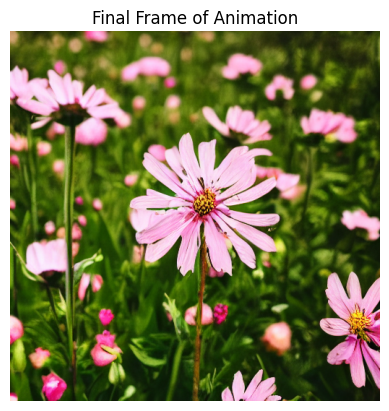

In [1]:
# 1. Install required libraries
!pip install diffusers transformers accelerate

import torch
from diffusers import StableDiffusionPipeline
from PIL import Image
import matplotlib.pyplot as plt

# 2. Load the Stable Diffusion Pipeline (Requires GPU)
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

# 3. Define a sequence of prompts to simulate a "Growth" animation
# We change the text slightly to tell the AI to 'move' the subject
prompts = [
    "A small green sprout in the soil, cinematic, detailed",
    "A small plant with two leaves growing from soil, cinematic, detailed",
    "A beautiful flower blooming in the garden, cinematic, detailed"
]

frames = []
print("Starting Animation Generation...")

for i, p in enumerate(prompts):
    print(f"Generating Frame {i+1}...")
    # Using a fixed manual_seed ensures the background and colors stay consistent
    generator = torch.Generator("cuda").manual_seed(42)

    frame = pipe(p, generator=generator, num_inference_steps=30).images[0]
    frames.append(frame)
    frame.save(f"frame_{i}.png")

# 4. Create a GIF to simulate the animation
# duration=500 means each frame stays for 0.5 seconds
frames[0].save(
    "ai_animation.gif",
    save_all=True,
    append_images=frames[1:],
    duration=500,
    loop=0
)

print("Animation saved as ai_animation.gif!")

# 5. Display the final frame
plt.imshow(frames[-1])
plt.axis("off")
plt.title("Final Frame of Animation")
plt.show()